In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xlrd

In [2]:
df = pd.read_excel('US Superstore data.xls')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

Notre dataset comporte 9994 echantillons et il n'y a pas de valeurs nulles dans nos données.  
Nos différentes variables sont :  
* Row ID: Unique ID for each row.
* Order ID: Unique Order ID for each Customer.
* Order Date: Order Date of the product.
* Ship Date: Shipping Date of the Product.
* Ship Mode: Shipping Mode specified by the Customer.
* Customer ID: Unique ID to identify each Customer.
* Customer Name: Name of the Customer.
* Segment: The segment where the Customer belongs.
* Country: Country of residence of the Customer.
* City: City of residence of the Customer.
* State: State of residence of the Customer.
* Postal Code: Postal Code of every Customer.
* Region: Region where the Customer belongs.
* Product ID: Unique ID of the Product.
* Category: Category of the product ordered.
* Sub-Category: Sub-Category of the product ordered.
* Product Name: Name of the Product.
* Sales: Sales of the Product.
* Quantity: Quantity of the Product.
* Discount: Discount provided.
* Profit: Profit/Loss incurred.

### **États qui enregistrent le plus de ventes**

In [4]:
df['State'].value_counts().head(10)

State
California        2001
New York          1128
Texas              985
Pennsylvania       587
Washington         506
Illinois           492
Ohio               469
Florida            383
Michigan           255
North Carolina     249
Name: count, dtype: int64

Ici, la Californie est le pays qui vend le plus avec 2001 vente, suivie de New York (1128), le Texas (985) ou encore la Pennsylvanie (587) et la Washington (506).  
Le graphique ci-dessons présente les 10 pays qui ont le plus vendu :

In [5]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

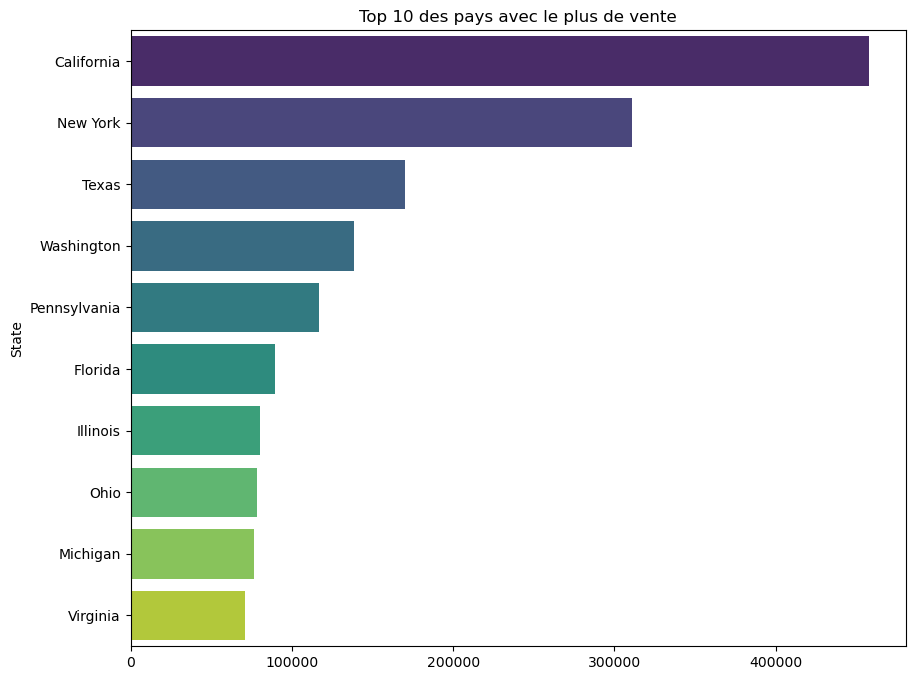

In [6]:
plt.figure(figsize=(10,8), dpi=100)
sns.barplot( x=top_states.values,
    y=top_states.index, hue=top_states.index,
    palette='viridis')
plt.title('Top 10 des pays avec le plus de vente')
plt.show();

### **Chiffre d'affaires total et les bénéfices de New York et de la Californie**

In [7]:
california = df[df['State'] == "California"]

In [8]:
new_york = df[df['State'] == "New York"]

In [9]:
sales = pd.DataFrame({
    'State': ['California', 'New York'],
    'Sales': [
        california['Sales'].sum(),
        new_york['Sales'].sum()
    ],
    'Profit': [
        california['Profit'].sum(),
        new_york['Profit'].sum()
    ]
})


In [10]:
sales

,State,Sales,Profit
0,California,457687.6315,76381.3871
1,New York,310876.2710,74038.5486


In [11]:
dif = sales['Sales'][0] - sales['Sales'][1]

In [12]:
profit = sales['Profit'][0] - sales['Profit'][1]

In [13]:
dif

np.float64(146811.36050000007)

In [14]:
profit

np.float64(2342.838499999998)

Entre la Californie et New York, il y a 146811.36$ de chiffre d'affaire

Cependant, même si la Californie a un chiffre d'affaire plus élévé que New York, il n'y a que 2342.84$ de bénéfice pour la Californie

Text(0, 0.5, 'Total Sales')

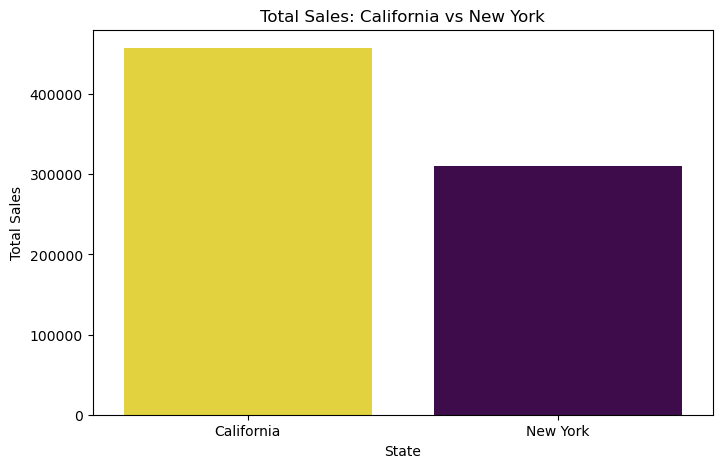

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=sales, x='State', y='Sales',hue='Sales', legend=False, palette='viridis')

plt.title('Total Sales: California vs New York')
plt.xlabel('State')
plt.ylabel('Total Sales')

On voit ici le chiffre d'affaire de chaque Etat

Text(0, 0.5, 'Total Profit')

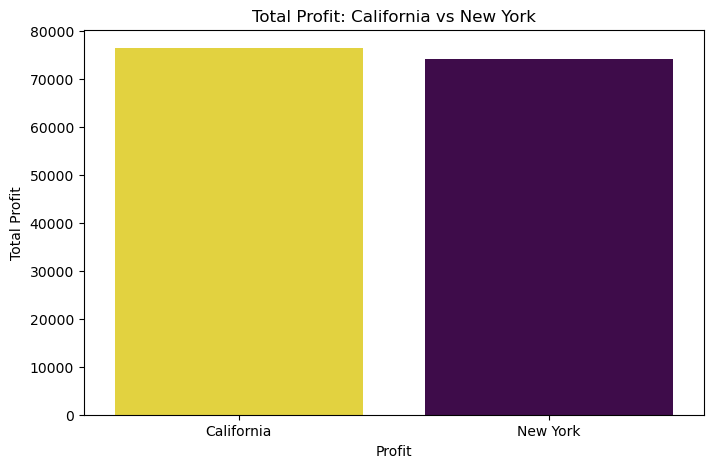

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(data=sales, x='State', y='Profit', hue='Profit',palette='viridis', legend=False)
plt.title('Total Profit: California vs New York')
plt.xlabel('Profit')
plt.ylabel('Total Profit')

On voit ici le bénéfice de chaque état

### **Client exceptionnel à New York**

In [46]:
new_york['Customer Name'].head(10).value_counts()

Customer Name
Ted Butterfield      7
Janet Molinari       2
Henry MacAllister    1
Name: count, dtype: int64

A New York, c'est le client Ted Butterfield qui est considéré comme un client exceptionnel car il a réalisé le plus de commande (7)

### **Différences de rentabilité entre les États**

Comparons le profit des états qui vendent le plus :

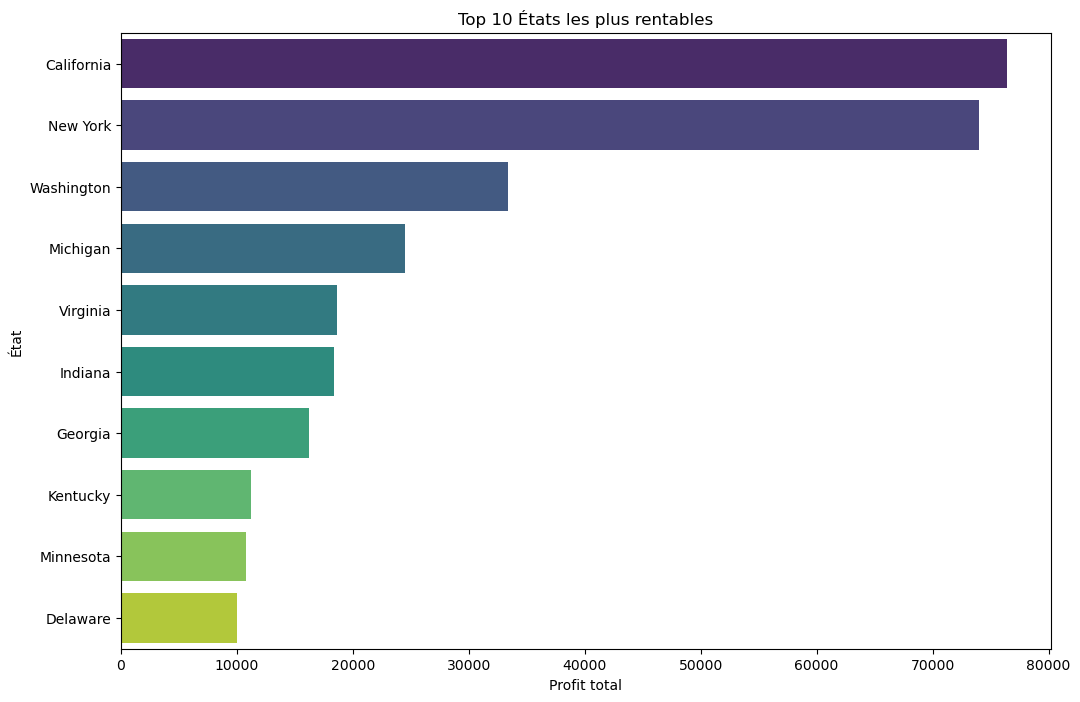

In [18]:
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(
    x=state_profit.head(10).values,
    y=state_profit.head(10).index,
    hue= state_profit.head(10).index,
    palette='viridis'
)

plt.title('Top 10 États les plus rentables')
plt.xlabel('Profit total')
plt.ylabel('État')
plt.show()

Ici on observe qu'il y a une grande différence de profit entre les pays. De plus, quand on prend le Texas qui avait un chiffre d'affaire plus élévé que Michigan, on constate que malgré le chiffre d'affaire d'élévé, il n'arrive pas à performer en terme de bénéfices 

### **Vérifions si le principe de Pareto (80/20) s'applique à nos données**

#### **Étape 1 : Calculons le profit par client**

In [21]:
client_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)

In [22]:
client_profit

Customer Name
Tamara Chand      8981.3239
Raymond Buch      6976.0959
Sanjit Chand      5757.4119
Hunter Lopez      5622.4292
Adrian Barton     5444.8055
                    ...    
Henry Goldwyn    -2797.9635
Sharelle Roach   -3333.9144
Luke Foster      -3583.9770
Grant Thornton   -4108.6589
Cindy Stewart    -6626.3895
Name: Profit, Length: 793, dtype: float64

On affiche ici le bénéfice que chaque client raporte, on remarque que Tamara Chand est le clieant qui raporte le plus avec des commande de 8981.32$

On peut remarqué ici qu'il y des clients avec un profit négatif, pour une analyse de paréto plus propre, nous pouvons les exclures

In [23]:
client_profit = client_profit[client_profit > 0]
client_profit = client_profit.sort_values(ascending=False)

#### **Étape 2 : Calculons les pourcentages cumulés**

In [24]:
pareto_df = client_profit.reset_index()
pareto_df.columns = ['Customer', 'Profit']


In [25]:
# Profit cumulé
pareto_df['Cumul_Profit'] = pareto_df['Profit'].cumsum()

In [26]:
pareto_df.head()

,Customer,Profit,Cumul_Profit
0,Tamara Chand,8981.3239,8981.3239
1,Raymond Buch,6976.0959,15957.4198
2,Sanjit Chand,5757.4119,21714.8317
3,Hunter Lopez,5622.4292,27337.2609
4,Adrian Barton,5444.8055,32782.0664


In [27]:
# % cumulé du profit
pareto_df['Cumul_profit_percent'] = (
    pareto_df['Cumul_Profit'] /
    pareto_df['Profit'].sum()
) * 100

In [28]:
pareto_df.head()

,Customer,Profit,Cumul_Profit,Cumul_profit_percent
0,Tamara Chand,8981.3239,8981.3239,2.511405
1,Raymond Buch,6976.0959,15957.4198,4.462097
2,Sanjit Chand,5757.4119,21714.8317,6.072015
3,Hunter Lopez,5622.4292,27337.2609,7.644188
4,Adrian Barton,5444.8055,32782.0664,9.166693


In [29]:
# % cumulé des clients
pareto_df['Customer_percent'] = (
    np.arange(1, len(pareto_df) + 1) /
    len(pareto_df)
) * 100

In [30]:
pareto_df.head()

,Customer,Profit,Cumul_Profit,Cumul_profit_percent,Customer_percent
0,Tamara Chand,8981.3239,8981.3239,2.511405,0.156740
1,Raymond Buch,6976.0959,15957.4198,4.462097,0.313480
2,Sanjit Chand,5757.4119,21714.8317,6.072015,0.470219
3,Hunter Lopez,5622.4292,27337.2609,7.644188,0.626959
4,Adrian Barton,5444.8055,32782.0664,9.166693,0.783699


#### **Étape 3 : Déterminons la part du profit générée par les 20 % des clients**

In [31]:
top_20_client = int(len(pareto_df) * 0.20)

profit_top_20 = pareto_df.iloc[:top_20_client]['Profit'].sum()
total_profit = pareto_df['Profit'].sum()

profit_percentage = (profit_top_20 / total_profit) * 100

print(f"Les 20% des clients génèrent {profit_percentage:.2f}% du profit total.")

Les 20% des clients génèrent 58.80% du profit total.


#### **Visualisation (diagramme de Pareto)**

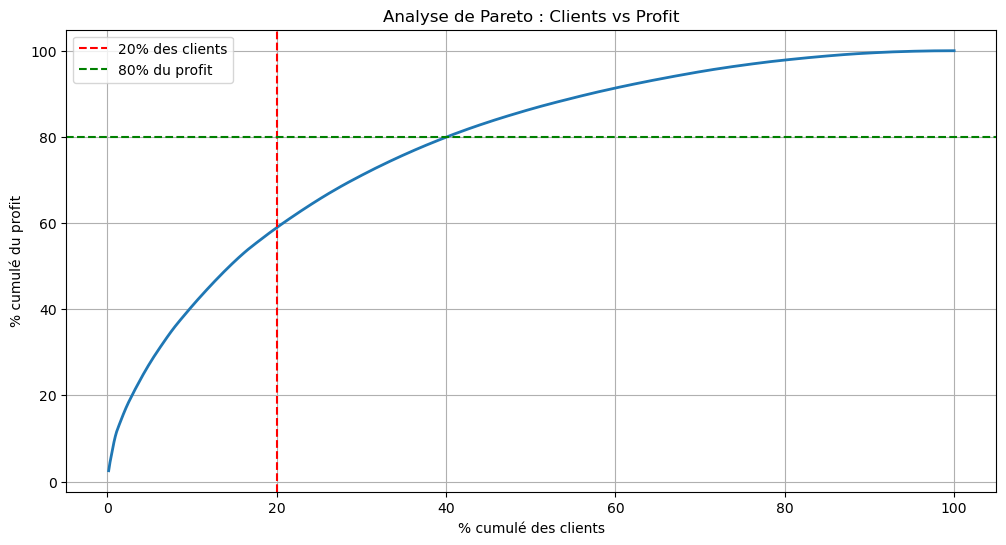

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(
    pareto_df['Customer_percent'],
    pareto_df['Cumul_profit_percent'],
    linewidth=2
)

plt.axvline(20, color='red', linestyle='--', label='20% des clients')
plt.axhline(80, color='green', linestyle='--', label='80% du profit')

plt.xlabel('% cumulé des clients')
plt.ylabel('% cumulé du profit')
plt.title('Analyse de Pareto : Clients vs Profit')
plt.legend()
plt.grid(True)

plt.show()

On remarque que pour 20% des clients (lignes rouge verticale), on est a environ 60% du profit cumulé or pour atteindre 80% du profit (ligne verte horizontale), il faut environ 40% des clients.  
On peut en conclure que le principe de pareto ne s'applique pas strictement à nos données.

In [33]:
df.groupby('Customer Name')['Profit'].sum().sort_values().head(10)

Customer Name
Cindy Stewart      -6626.3895
Grant Thornton     -4108.6589
Luke Foster        -3583.9770
Sharelle Roach     -3333.9144
Henry Goldwyn      -2797.9635
Nathan Cano        -2204.8072
Sean Braxton       -2082.7451
Sean Miller        -1980.7393
Christine Phan     -1850.3029
Natalie Fritzler   -1695.9714
Name: Profit, dtype: float64

#### **Les 20 premières villes en fonction du chiffre d'affaire**

In [34]:
top_20_ville = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)

In [35]:
top_20_ville

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64

Ici, on voit le top 20 des villes en fonction de leur chiffres d'affaire. On peut voir New York City avec un chiffre d'affaire de 256368.16$, Los Angeles (175851.34$), Seattle (119540.74), San Francisco (112669.09$), Philadelphia (109077.01$).  
Le graphique ci-dessous présente plus distinctement ces villes

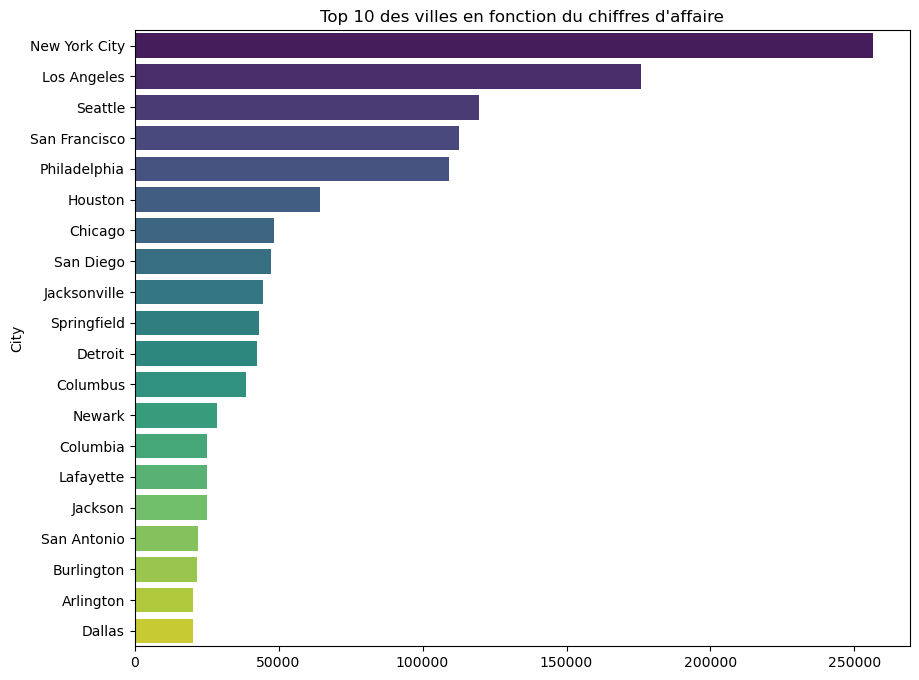

In [36]:
plt.figure(figsize=(10,8), dpi=100)
sns.barplot( x=top_20_ville.values,
    y=top_20_ville.index, hue=top_20_ville.index,
    palette='viridis')
plt.title('Top 10 des villes en fonction du chiffres d\'affaire')
plt.show();

#### **Top 20 premières villes en termes de bénéfice**

In [37]:
top_20_ville_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)

In [38]:
top_20_ville_profit

City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897.1013
Newark            5793.7588
Columbia          5606.1167
Richmond          5567.2486
Providence        5505.6569
Henderson         4911.8609
Arlington         4169.6969
Lakewood          3234.0278
Milwaukee         2793.0851
Name: Profit, dtype: float64

On remarque ici New York City est la ville avec le plus de profit (62036.98$), suivis par Los Angeles (30440.75$), Seattle (29156.09$), San Francisco (17507.38$), Detroit (13181.79$) et Lafayette (10018.38$).  
Le graphique ci-dessous présente mieux les villes avec de meilleur profit

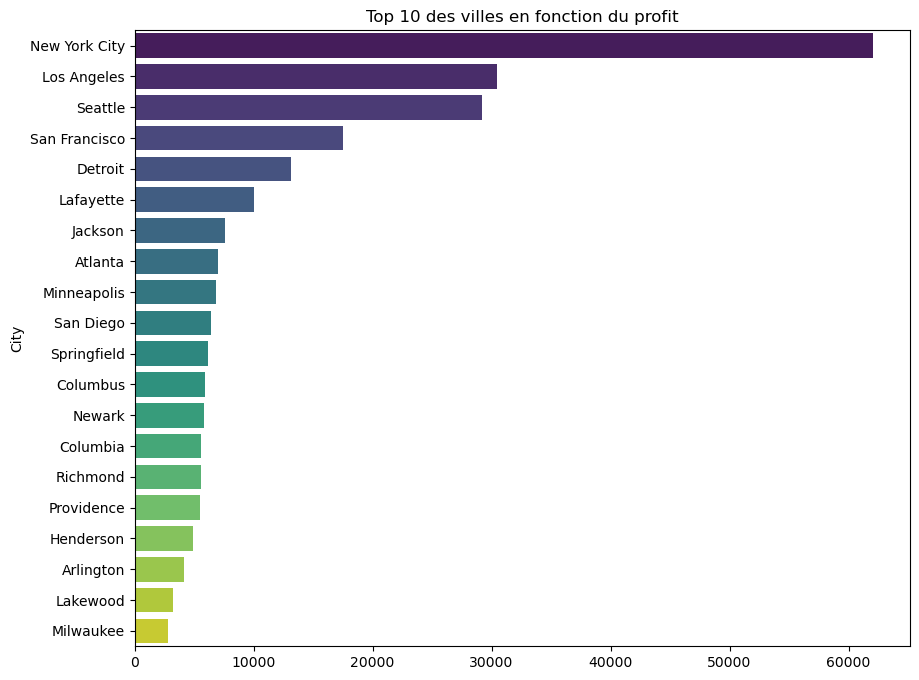

In [39]:
plt.figure(figsize=(10,8), dpi=100)
sns.barplot( x=top_20_ville_profit.values,
    y=top_20_ville_profit.index, hue=top_20_ville_profit.index,
    palette='viridis')
plt.title('Top 10 des villes en fonction du profit')
plt.show();

On remarque aussi qu'il y a une différence de rentabilité entre ces villes, les villes avec un plus gros chiffre d'affaire sont plus rentable que les villes avec un petit chiffre d'affaire

#### **Top 20 meilleurs clients en termes de ventes**

In [40]:
top_client= df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)

In [41]:
top_client

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64

Sean Miller est le client principale en terme de vente vente avec environ 25043.05$, suivie par Tamara Chand (19052.21$) et Raymond Buch (15117.33$).  

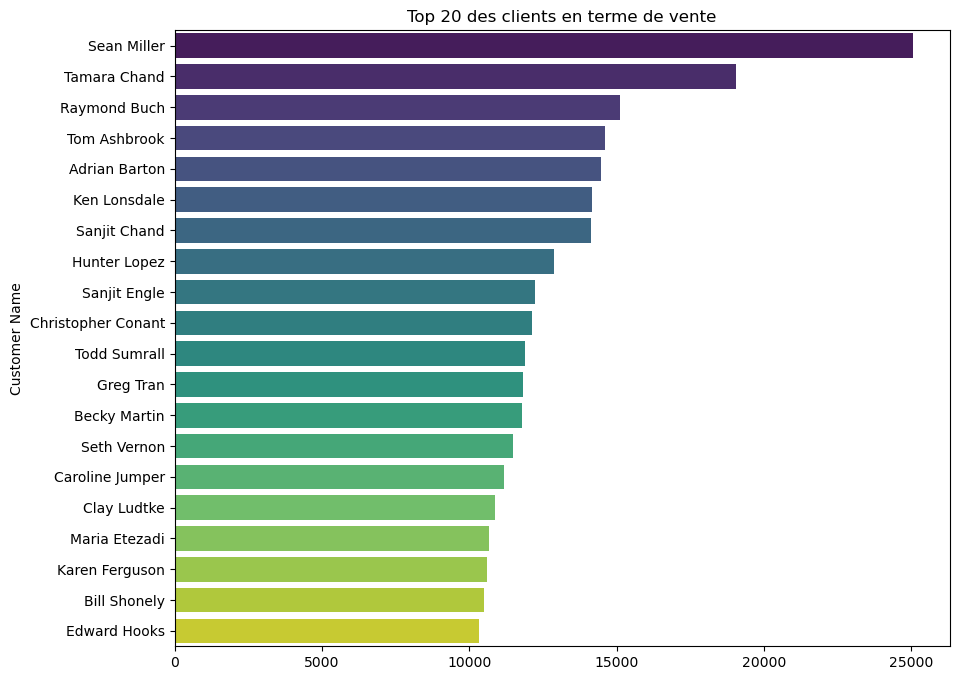

In [42]:
plt.figure(figsize=(10,8), dpi=100)
sns.barplot( x=top_client.values,
    y=top_client.index, hue=top_client.index,
    palette='viridis')
plt.title('Top 20 des clients en terme de vente')
plt.show();

#### **Principe de pareto aux clients et aux ventes**

In [43]:
# Ventes par client
client_sales = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
)

# DataFrame Pareto
pareto_sales = client_sales.reset_index()
pareto_sales.columns = ['Customer', 'Sales']

# Ventes cumulées
pareto_sales['Cumul_sales'] = pareto_sales['Sales'].cumsum()

# % cumulé des ventes
pareto_sales['Cumul_sales_percent'] = (
    pareto_sales['Cumul_sales']
    / pareto_sales['Sales'].sum()
) * 100

# % cumulé des clients
pareto_sales['Client_percent'] = (
    np.arange(1, len(pareto_sales) + 1)
    / len(pareto_sales)
) * 100


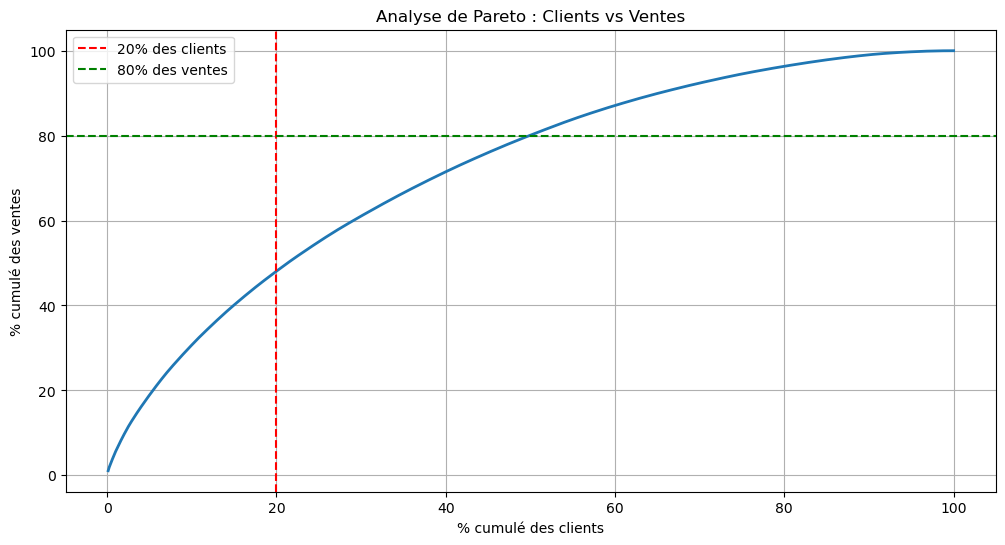

In [44]:
# Courbe de Pareto
plt.figure(figsize=(12, 6))

plt.plot(
    pareto_sales['Client_percent'],
    pareto_sales['Cumul_sales_percent'],
    linewidth=2
)

plt.axvline(20, color='red', linestyle='--', label='20% des clients')
plt.axhline(80, color='green', linestyle='--', label='80% des ventes')

plt.xlabel('% cumulé des clients')
plt.ylabel('% cumulé des ventes')
plt.title('Analyse de Pareto : Clients vs Ventes')
plt.legend()
plt.grid(True)

plt.show()

Pour atteindre 80% des ventes, il faut environ 50% des clients or dans notre dans notre graphique, pour 20% des clients on a environ 45% des ventes.  
Le principe de pareto ne s'applique pas ici.

## **Résultat final**

Dans nos analyses, nous avons remarqué qu'avoir un plus gros chiffre ne signifie pas avoir de bons bénéfices, surtout en fonction des États Cependant nous avons deux possibilités : soit cibler chaque ville directement car elles ont tendance à avoir un plus gros bénéfice en fonction de leur chiffre d'affaires, soit cibler les États où un plus gros chiffre ne signifie pas un plus gros bénéfice.  

Dans le cas où l'on veut viser les villes, il faudrait se concentrer sur cinq principales villes : New York City, Los Angeles, Seattle, San Francisco, Philadelphie.  

Et dans le cas où l'on viserait chaque état, il faudrait se concentrer sur les états avec de meilleurs profits comme la Californie, New York, Washington, le Michigan, la Virginie et l'Indiana.